<a href="https://colab.research.google.com/github/mykhailodolitsoi/ML_RASHKA/blob/main/RASHKA_ML_2_Perceptron_Adaline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Perceptron, Adaline

This notebook implements a binary perceptron and Adaline classifier from scratch
and applies it to a subset of the Iris dataset.

Source:
*Machine Learning with PyTorch and Scikit-Learn*, Chapter 2.


In [ ]:
import numpy as np
import os
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## Perceptron class

The perceptron is a linear binary classifier that updates its weights
based on misclassified samples using a simple learning rule.


In [ ]:
class Perceptron:
    """Binary perceptron classifier.

    Parameters
    ----------
    lr : float
        Learning rate.
    n_epochs : int
        Number of training epochs.
    random_state : int
        Seed for random initialization.


    Attributes
    ----------
    w_ : ndarray of shape (n_features,)
        Weight vector after fitting.
    b_ : float
        Bias term after fitting.
    errors_ : list[int]
        Number of misclassifications in each epoch.
    """

    def __init__(self, lr=0.01, n_epochs=50, random_state=1):
        self.lr = lr
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        """Fit the perceptron model.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Training input samples.
        y : ndarray of shape (n_samples,)
            Binary class labels encoded as {0, 1}.

        Returns
        -------
        self : Perceptron
            Fitted estimator.
        """
        rgen = np.random.RandomState(self.random_state)

        self.w_ = rgen.normal(loc=0.0,
                              scale=0.01,
                              size=X.shape[1])
        self.b_ = np.float32(0.)
        self.errors_ = []

        for _ in range(self.n_epochs):
            errors = 0
            for xi, label in zip(X, y):
                update = self.lr * (label - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0)
            self.errors_.append(errors)

        return self

    def net_input(self, X):
        """Compute linear net input."""
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        """Return class label prediction."""
        return np.where(self.net_input(X) >= 0.0, 1, 0)

## Data loading

We load the Iris dataset directly from the UCI repository.
Only the first 100 samples are used to form a binary classification task.


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
df = pd.read_csv(url, header=None)
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Data preparation

- Classes used: *Setosa* vs *Versicolor*
- Labels are encoded as {0, 1}
- Two features are selected to allow 2D visualization


In [ ]:
y = df.iloc[0:100, 4].values
y = np.where(y == "Iris-setosa", 0, 1)

X = df.iloc[0:100, [0, 2]].values

## Data visualization

Scatter plot of the two selected features.


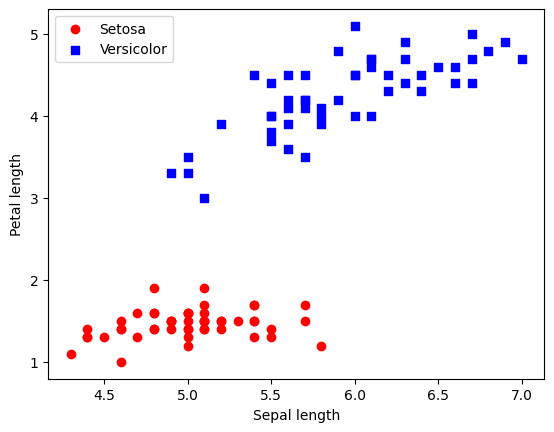

In [ ]:
plt.scatter(X[:50, 0], X[:50, 1], color="red", marker="o", label="Setosa")
plt.scatter(X[50:100, 0], X[50:100, 1], color="blue", marker="s", label="Versicolor")
plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.legend()
plt.show()


## Perceptron model training

The perceptron is trained for a fixed number of epochs.
The number of weights update per epoch is recorded.

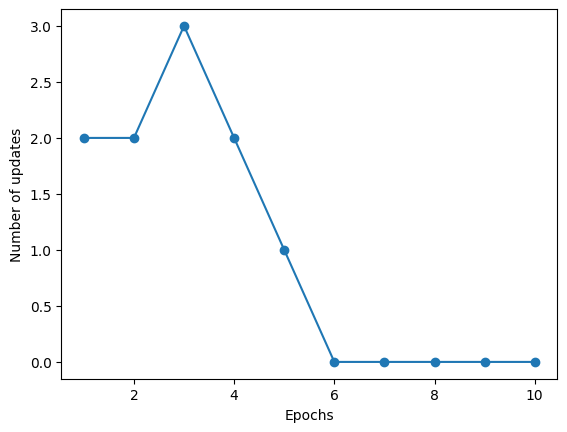

In [ ]:
ppn = Perceptron(lr=0.1, n_epochs=10)
ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker="o")
plt.xlabel("Epochs")
plt.ylabel("Number of updates")
plt.show()


## Decision boundary visualization

The learned linear decision boundary is visualized in feature space.


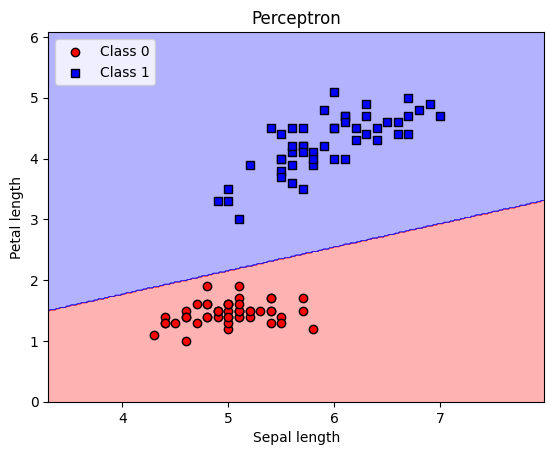

In [ ]:
def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ("o", "s", "^", "v")
    colors = ("red", "blue", "lightgreen", "gray")
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            X[y == cl, 0],
            X[y == cl, 1],
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black"
        )

plot_decision_regions(X, y, classifier=ppn)
plt.title("Perceptron")
plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.legend(loc="upper left")
plt.show()


## AdalineGD class

Adaline (Adaptive Linear Neuron) is a linear classifier that updates its
weights by minimizing the mean squared error (MSE) loss using
batch gradient descent.

Unlike the perceptron, weight updates are performed after evaluating
the loss over the entire training dataset.


In [ ]:
class AdalineGD:
    """Adaline classifier.

    Parameters
    ----------
    lr : float
        Learning rate.
    n_epochs : int
        Number of training epochs.
    random_state : int
        Seed for random initialization.


    Attributes
    ----------
    w_ : ndarray of shape (n_features,)
        Weight vector after fitting.
    b_ : float
        Bias term after fitting.
    losses_ : list[float]
        Mean squared error (MSE) value for each epoch.
    """

    def __init__(self, lr=0.01, n_epochs=50, random_state=1):
        self.lr = lr
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        """Fit the Adaline model.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Training input samples.
        y : ndarray of shape (n_samples,)
            Binary class labels encoded as {0, 1}.

        Returns
        -------
        self : AdalineGD
            Fitted estimator.
        """
        rgen = np.random.RandomState(self.random_state)

        self.w_ = rgen.normal(loc=0.0,
                              scale=0.01,
                              size=X.shape[1])
        self.b_ = np.float32(0.)
        self.losses_ = []

        for _ in range(self.n_epochs):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y-output)
            self.w_ += self.lr * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.lr * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """Compute linear net input."""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Calculating linear input"""
        return X

    def predict(self, X):
        """Return class label prediction."""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

## Learning rate experiments

This section investigates the effect of different learning rate values
on the convergence behavior of the Adaline algorithm, highlighting the
difference between overly large and overly small learning rates.

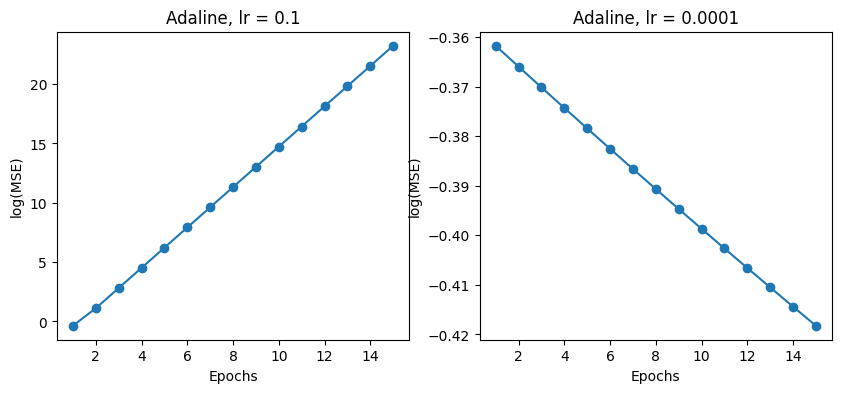

In [ ]:
from matplotlib import markers
fig, ax = plt.subplots(nrows=1,
                      ncols=2,
                      figsize=(10, 4))

ada1 = AdalineGD(n_epochs=15, lr=0.1).fit(X, y)
ax[0].plot(range(1, len(ada1.losses_) + 1), np.log10(ada1.losses_), marker='o')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("log(MSE)")
ax[0].set_title("Adaline, lr = 0.1")

ada2 = AdalineGD(n_epochs=15, lr=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.losses_) + 1), np.log10(ada2.losses_), marker='o')
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("log(MSE)")
ax[1].set_title("Adaline, lr = 0.0001")
plt.show()

## Data standardization

Feature standardization is applied using population standard deviation
to bring all input features to zero mean and unit variance, improving
the convergence behavior of gradient-based optimization.


In [ ]:
X_std = np.copy(X)

X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

## AdalineGD model training

The AdalineGD model is trained for a fixed number of epochs using
batch gradient descent. Input features are standardized prior to
training to ensure stable convergence. Model parameters (weights and
bias) are updated once per epoch after processing the entire training
dataset.

In [ ]:
ada3 = AdalineGD(n_epochs=20, lr=0.5)
ada3.fit(X_std, y)

## Decision boundary and loss visualization

The learned linear decision boundary is visualized in feature space.


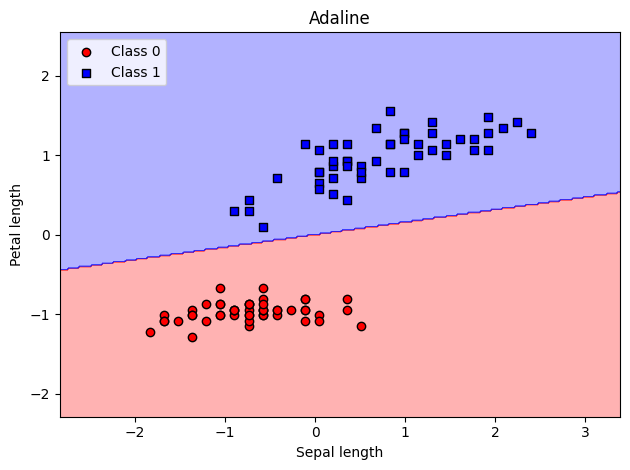

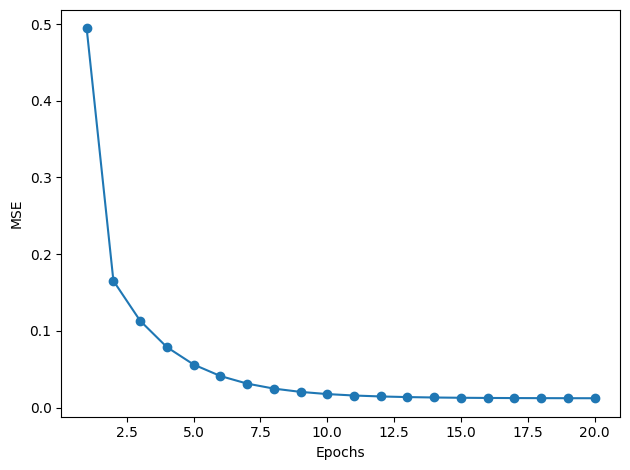

In [ ]:
plot_decision_regions(X_std, y, classifier=ada3)

plt.title("Adaline")
plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

plt.plot(range(1, len(ada3.losses_) + 1), ada3.losses_, marker="o")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

## AdalineSGD

This class implements the AdalineGD algorithm using Stochastic Gradient Descent (SGD)
instead of batch gradient descent. Unlike AdalineGD, the model parameters
(weights and bias) are updated after each training sample rather than
once per epoch. SGD can lead to faster convergence and allows online learning.

In [18]:
class AdalineSGD:
    """AdalineSGD classifier.

    Parameters
    ----------
    lr : float
        Learning rate.
    n_epochs : int
        Number of training epochs.
    shuffle: bool
        Shuffle the training dataset
    random_state : int
        Seed for random initialization.


    Attributes
    ----------
    w_ : ndarray of shape (n_features,)
        Weight vector after fitting.
    b_ : float
        Bias term after fitting.
    losses_ : list[float]
        Mean squared error (MSE) value for each epoch.
    """

    def __init__(self,
                 lr=0.1,
                 n_epochs=10,
                 shuffle=True,
                 random_state=1):
        self.lr = lr
        self.n_epochs = n_epochs
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        """Fit the Adaline model.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Training input samples.
        y : ndarray of shape (n_samples,)
            Binary class labels encoded as {0, 1}.

        Returns
        -------
        self : AdalineSGD
            Fitted estimator.
        """

        self._initialize_wieghts(X.shape[1])
        self.losses_ = []

        for _ in range(self.n_epochs):
            if self.shuffle:
                X, y = self._shuffle_arrays(X, y)
            losses = []

            for xi, target, in zip(X, y):
                losses.append(self._update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses_.append(avg_loss)
        return self

    def partial_fit(self, X, y):
        """Fitting the model without repeated weights initialization"""
        if not self.w_initialized:
            self._initialize_wieghts(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def _shuffle_arrays(self, X, y):
        """Shuffle the training data and targets"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _initialize_wieghts(self, m):
        """Weights initialization"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0,
                                    scale=0.01,
                                    size=m)
        self.b_ = np.float32(0.)
        self.w_initialized = True

    def _update_weights(self, xi, target):
        """Using Adaline rule for updating weights"""
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_ += self.lr * 2.0 * xi * error
        self.b_ += self.lr * 2.0 * error
        loss = error**2
        return loss

    def net_input(self, X):
        """Compute linear net input."""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Calculating linear input"""
        return X

    def predict(self, X):
        """Return class label prediction."""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [21]:
ada_sgd = AdalineSGD(n_epochs=15,
                     lr=0.01,
                     random_state=1)
ada_sgd.fit(X_std, y)

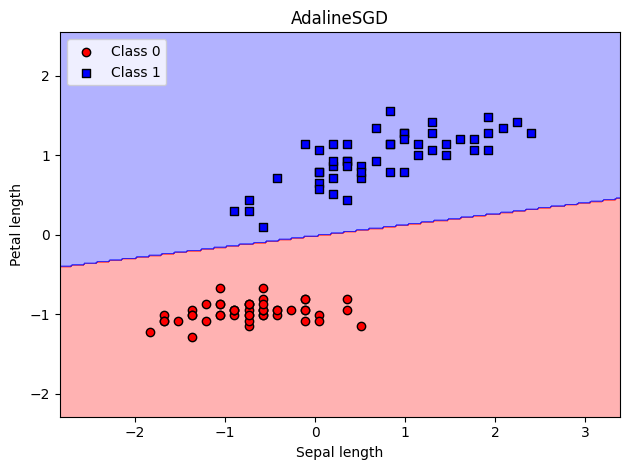

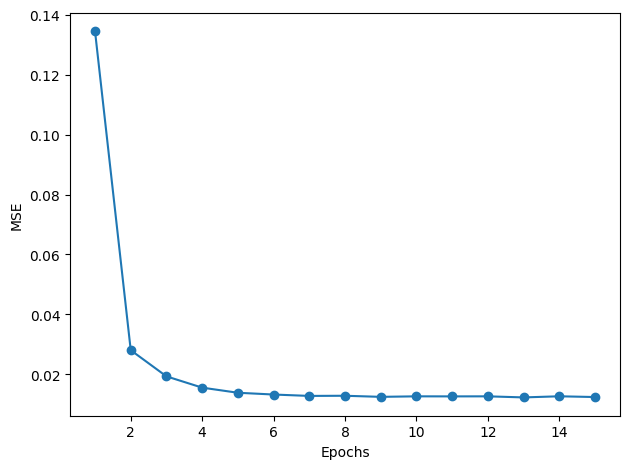

In [22]:
plot_decision_regions(X_std, y,
                      classifier=ada_sgd)
plt.title("AdalineSGD")
plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

plt.plot(range(1, len(ada_sgd.losses_) + 1), ada_sgd.losses_, marker = "o")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()